In [1]:
import os
import sys

import pandas as pd

import json
from IPython.display import Image, Markdown, display

# Determine the root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Insert at the beginning of sys.path to prioritize local modules,
# and check if it exists to prevent duplicates when re-running the cell.
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from workflow_engine.agents.cleaning_agent import clean_data_node
from workflow_engine.agents.eda_agent import eda_agent_node
from workflow_engine.agents.feature_engineering_agent import feature_engineering_agent_node
from workflow_engine.agents.modelling_agent import modelling_agent_node
from workflow_engine.agents.reporting_agent import reporting_agent_node

In [2]:
# Define the path relative to the notebook
dataset_path = "../data/raw/Heart_disease_statlog.csv"

# Quick check to ensure the file exists where we expect it
if os.path.exists(dataset_path):
    print(f"Successfully located dataset at: {dataset_path}")
    df_preview = pd.read_csv(dataset_path)
    display(df_preview.head())
else:
    print(f"Error: Could not find dataset at {dataset_path}. Check your folder structure.")

Successfully located dataset at: ../data/raw/Heart_disease_statlog.csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [3]:
# Initialize the state with the real Heart Disease dataset
state = {
    "messages": [],
    "user_request": "Clean the data and perform exploratory data analysis.",
    "target_variable": "target",  # The actual target column in the statlog dataset
    "raw_dataset_path": "data/raw/Heart_disease_statlog.csv", # Relative to project root
    "current_dataset_path": "data/raw/Heart_disease_statlog.csv",
    "artifacts": {},
    "current_step": "start",
    "error_flag": False,
    "error_message": None,
    "revision_count": 0
}

print(f"State initialized. Target Variable: {state['target_variable']}")

State initialized. Target Variable: target


In [4]:
print("--- RUNNING CLEANING AGENT ---")
cleaning_update = clean_data_node(state)
state.update(cleaning_update)

print("\nUpdated State Error Flag:", state["error_flag"])

# Inspect the cleaned data directly in the notebook
if not state["error_flag"]:
    cleaned_df = pd.read_csv(state["current_dataset_path"])
    display(cleaned_df.head())
else:
    print("Error:", state["error_message"])

--- RUNNING CLEANING AGENT ---
--- AGENT: DATA CLEANING ---

--- ATTEMPT 1/3 ---


Python REPL can execute arbitrary code. Use with caution.


Generated Code:
 import pandas as pd
import os

# Define file paths
input_filepath = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/raw/Heart_disease_statlog.csv'
output_dir = r'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/processed'
output_filepath = os.path.join(output_dir, 'cleaned_data.csv')

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# 1. Load the dataset
df = pd.read_csv(input_filepath)

# 2. Identify and handle missing values
# Calculate missing percentages for each column
missing_percentages = df.isnull().sum() / len(df)

# Identify columns to drop (more than 50% missing)
cols_to_drop = missing_percentages[missing_percentages > 0.5].index
df = df.drop(columns=cols_to_drop)

# Impute numerical columns with their median
# Select numerical columns that still have missing values
numerical_cols_with_nan = df.select_dtypes(include=['number']).columns[df.select_d

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [5]:
print("--- RUNNING EDA AGENT ---")

if not state["error_flag"]:
    eda_update = eda_agent_node(state)
    state.update(eda_update)
    
    print("\nUpdated Artifacts Dictionary:")
    print(state.get("artifacts"))
else:
    print("Skipping EDA due to previous error.")

--- RUNNING EDA AGENT ---
--- AGENT: EXPLORATORY DATA ANALYSIS ---

--- ATTEMPT 1/3 ---
Generated Code:
 import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

# Define file paths
cleaned_data_path = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/processed/cleaned_data.csv'
figures_dir = r'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/reports/figures'
artifacts_dir = r'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/artifacts'
eda_summary_path = os.path.join(artifacts_dir, 'eda_summary.json')
correlation_heatmap_path = os.path.join(figures_dir, 'correlation_heatmap.png')
target_distribution_path = os.path.join(figures_dir, 'target_distribution.png')

# 1. Load the dataset
df = pd.read_csv(cleaned_data_path)

# 2. Create output directories
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(artifacts_dir, exist_ok=True)

# 3. Generate a com


--- Displaying: correlation_heatmap ---


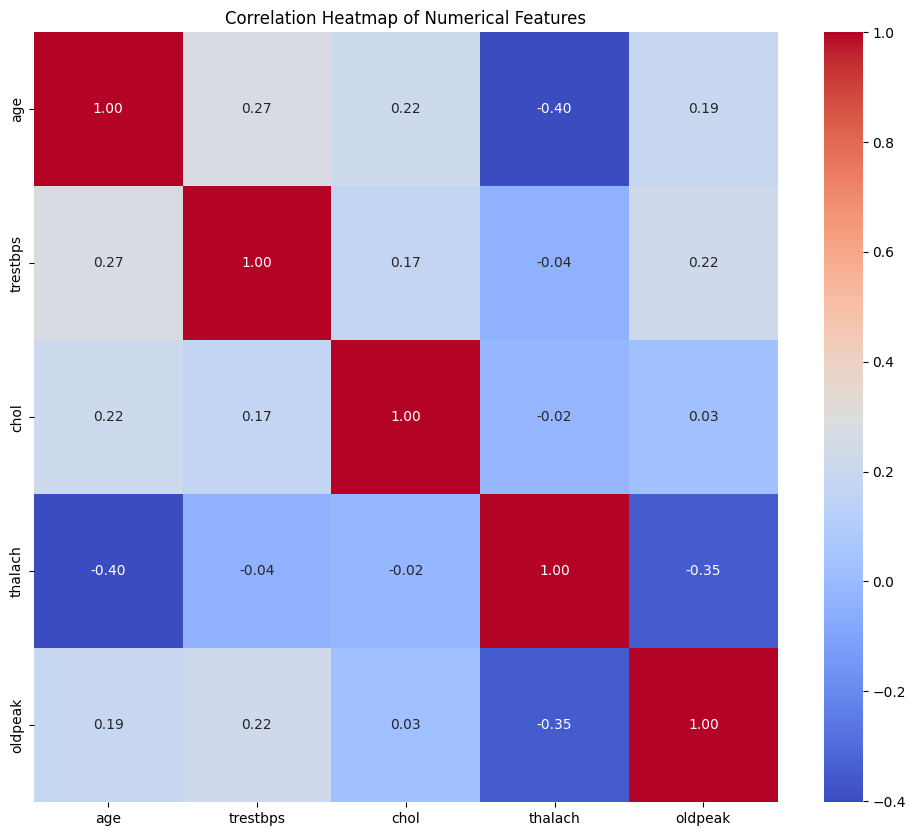


--- Displaying: target_distribution ---


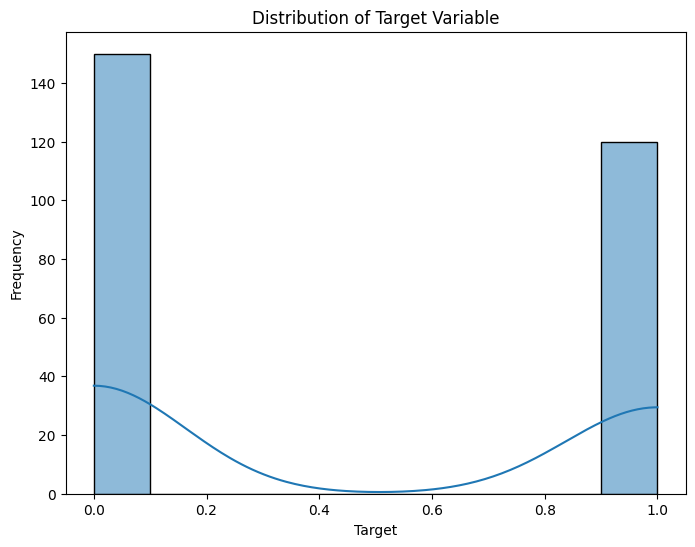


--- Displaying: eda_summary ---
{
  "age": {
    "type": "numerical_feature",
    "min": 29.0,
    "max": 77.0,
    "mean": 54.43333333333333,
    "skewness": -0.16361522733654557
  },
  "sex": {
    "type": "categorical_feature",
    "cardinality": 2
  },
  "cp": {
    "type": "categorical_feature",
    "cardinality": 4
  },
  "trestbps": {
    "type": "numerical_feature",
    "min": 94.0,
    "max": 200.0,
    "mean": 131.34444444444443,
    "skewness": 0.7226180070438306
  },
  "chol": {
    "type": "numerical_feature",
    "min": 126.0,
    "max": 564.0,
    "mean": 249.65925925925927,
    "skewness": 1.1837208885656836
  },
  "fbs": {
    "type": "categorical_feature",
    "cardinality": 2
  },
  "restecg": {
    "type": "categorical_feature",
    "cardinality": 3
  },
  "thalach": {
    "type": "numerical_feature",
    "min": 71.0,
    "max": 202.0,
    "mean": 149.67777777777778,
    "skewness": -0.5277366828794363
  },
  "exang": {
    "type": "categorical_feature",
    "cardi

In [6]:
if "artifacts" in state and state["artifacts"]:
    for artifact_name, artifact_path in state["artifacts"].items():
        print(f"\n--- Displaying: {artifact_name} ---")
        
        # Handle JSON summaries
        if artifact_path.endswith('.json'):
            try:
                with open(artifact_path, 'r') as f:
                    data = json.load(f)
                    # Print the JSON nicely formatted
                    print(json.dumps(data, indent=2))
            except Exception as e:
                print(f"Failed to read JSON: {e}")
                
        # Handle Images
        elif artifact_path.endswith(('.png', '.jpg', '.jpeg')):
            try:
                display(Image(filename=artifact_path))
            except Exception as e:
                print(f"Failed to display image: {e}")
                
        # Handle anything else
        else:
            print(f"Artifact saved at: {artifact_path}")
else:
    print("No artifacts found.")

In [7]:
print("--- RUNNING FEATURE ENGINEERING AGENT ---")

# 1. Execute the Agent
if not state["error_flag"]:
    fe_update = feature_engineering_agent_node(state)
    state.update(fe_update) # Update the global state with the new dataset path

# 2. Verify the Results
if not state["error_flag"] and os.path.exists(state["current_dataset_path"]):
    print(f"\nSuccess! Engineered Dataset saved to: {state['current_dataset_path']}")
    print("\n--- PREVIEWING ENGINEERED DATASET ---")
    
    # Load the newly transformed data
    df_engineered = pd.read_csv(state["current_dataset_path"])
    
    display(df_engineered.head())
    print(f"\nNew Shape: {df_engineered.shape}")
    print("\nColumns:")
    print(df_engineered.columns.tolist())
    
elif state["error_flag"]:
    print(f"\nFeature Engineering Failed: {state.get('error_message')}")

--- RUNNING FEATURE ENGINEERING AGENT ---
--- AGENT: FEATURE ENGINEERING ---

--- ATTEMPT 1/3 ---
Generated Code:
 import pandas as pd
import os
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
input_path = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/processed/cleaned_data.csv'
df = pd.read_csv(input_path)

# 2. Ensure the output directory exists
output_dir = r'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/processed'
os.makedirs(output_dir, exist_ok=True)

# 3. Separate the target variable 'target' from the features
target = df['target']
features_df = df.drop('target', axis=1)

# Identify categorical and numerical features based on the EDA Summary
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# 4. Apply One-Hot Encoding to categorical features
# Explicitly using the 'columns

--- RUNNING MODELLING AGENT ---
--- AGENT: MODELLING ---

--- ATTEMPT 1/3 ---
Generated Code:
 import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import json
import matplotlib.pyplot as plt
import os

# Define file paths
DATA_PATH = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/processed/engineered_data.csv'
ARTIFACTS_DIR = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/data/artifacts'
FIGURES_DIR = 'c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/reports/figures'
BEST_MODEL_PATH = os.path.join(ARTIFACTS_DIR, 'best_model.pkl')
MODEL_METRICS_PATH = os.path.join(ARTIFACTS_DIR, 'model_metrics.json')
CONFUSION_MATRIX_PATH = os

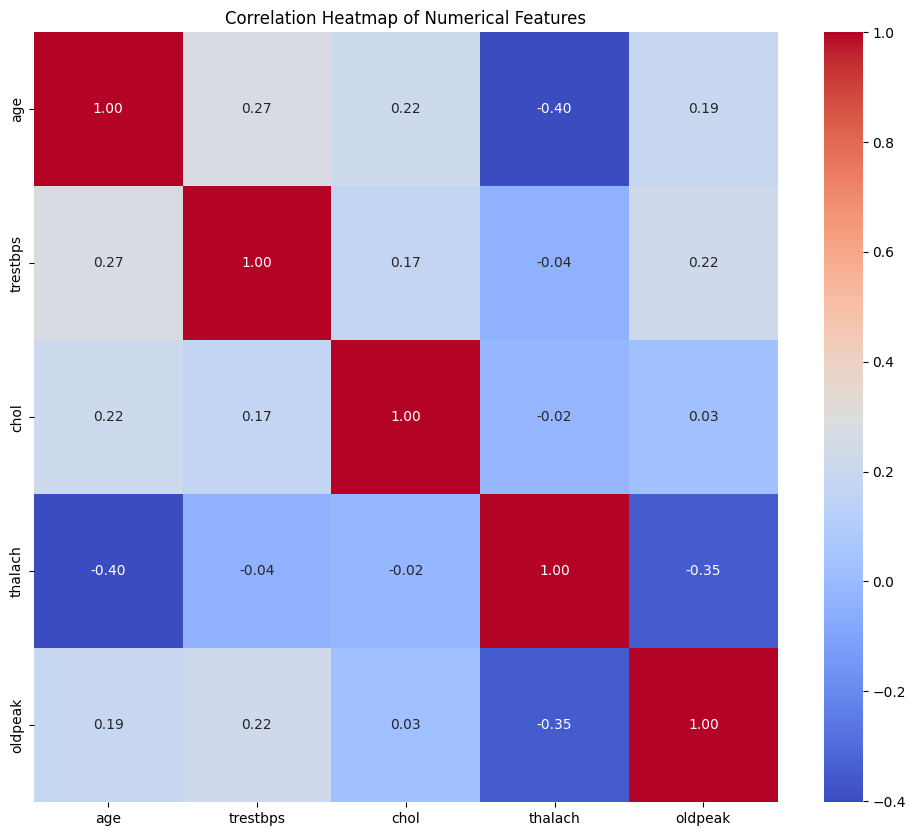


Displaying: target_distribution


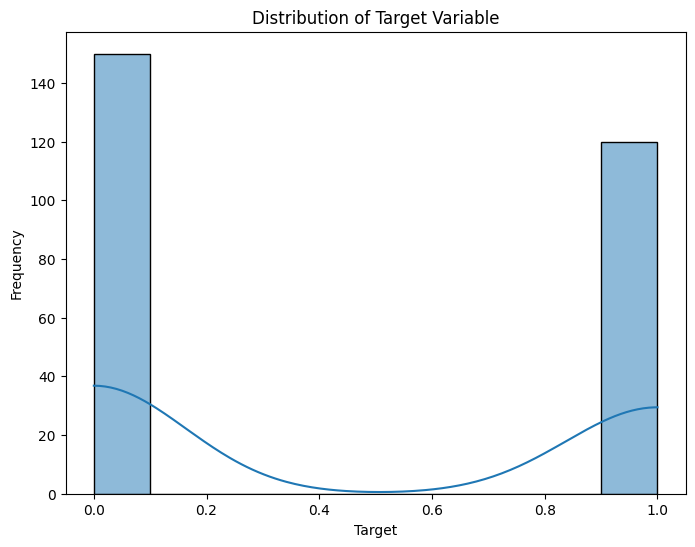


Displaying: eda_summary
{
  "age": {
    "type": "numerical_feature",
    "min": 29.0,
    "max": 77.0,
    "mean": 54.43333333333333,
    "skewness": -0.16361522733654557
  },
  "sex": {
    "type": "categorical_feature",
    "cardinality": 2
  },
  "cp": {
    "type": "categorical_feature",
    "cardinality": 4
  },
  "trestbps": {
    "type": "numerical_feature",
    "min": 94.0,
    "max": 200.0,
    "mean": 131.34444444444443,
    "skewness": 0.7226180070438306
  },
  "chol": {
    "type": "numerical_feature",
    "min": 126.0,
    "max": 564.0,
    "mean": 249.65925925925927,
    "skewness": 1.1837208885656836
  },
  "fbs": {
    "type": "categorical_feature",
    "cardinality": 2
  },
  "restecg": {
    "type": "categorical_feature",
    "cardinality": 3
  },
  "thalach": {
    "type": "numerical_feature",
    "min": 71.0,
    "max": 202.0,
    "mean": 149.67777777777778,
    "skewness": -0.5277366828794363
  },
  "exang": {
    "type": "categorical_feature",
    "cardinality":

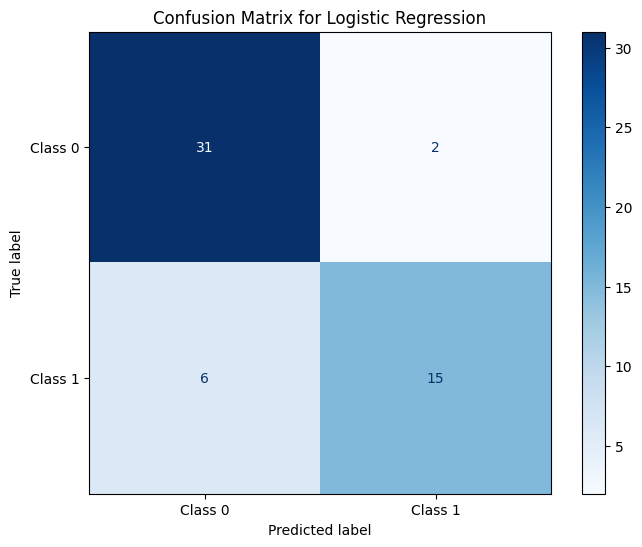

In [8]:
print("--- RUNNING MODELLING AGENT ---")

if not state["error_flag"]:
    modelling_update = modelling_agent_node(state)
    state.update(modelling_update)

print("\n--- FINAL PIPELINE ARTIFACTS ---")
if "artifacts" in state and state["artifacts"]:
    for artifact_name, artifact_path in state["artifacts"].items():
        print(f"\nDisplaying: {artifact_name}")
        
        if artifact_path.endswith('.json'):
            try:
                with open(artifact_path, 'r') as f:
                    print(json.dumps(json.load(f), indent=2))
            except:
                print(f"Artifact saved at: {artifact_path}")
        elif artifact_path.endswith(('.png', '.jpg')):
            try:
                display(Image(filename=artifact_path))
            except:
                pass
        else:
            print(f"File saved at: {artifact_path}")

In [9]:
print("--- RUNNING REPORTING AGENT ---")

# 1. Execute the Agent
if not state.get("error_flag"):
    reporting_update = reporting_agent_node(state)
    state.update(reporting_update)

# 2. Verify and Display the Results
if not state.get("error_flag") and "final_report" in state.get("artifacts", {}):
    report_path = state["artifacts"]["final_report"]
    print(f"\nSuccess! Final report saved to: {report_path}")
    print("\n" + "="*60 + "\n")
    
    # Load and render the markdown nicely in Jupyter
    try:
        with open(report_path, "r", encoding="utf-8") as f:
            report_text = f.read()
        display(Markdown(report_text))
    except Exception as e:
        print(f"Failed to read or display the report: {e}")
        
elif state.get("error_flag"):
    print(f"\nReporting Agent Failed: {state.get('error_message')}")
else:
    print("\nReporting Agent completed, but no 'final_report' artifact was found in the state.")

--- RUNNING REPORTING AGENT ---
--- AGENT: REPORTING ---
Status: Success - Report saved to c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/reports/final_reports/final_report.md

Success! Final report saved to: c:/Users/risha/OneDrive/Documents/ArtificialIntelligence/data-science-workflow/reports/final_reports/final_report.md




# Machine Learning Pipeline Report: Predictive Modeling for 'target'

## Executive Summary

This report summarizes the data cleaning, exploratory data analysis (EDA), and machine learning modeling performed to predict the `target` variable. The project aimed to develop a robust predictive model after thoroughly understanding the underlying data structure and characteristics. After a comprehensive pipeline, a Logistic Regression model was trained and evaluated, achieving strong performance metrics, including an accuracy of approximately 85.2%. This indicates a reliable capability to predict the `target` variable with a good balance between identifying positive cases and minimizing false alarms.

## Dataset Overview

The dataset consists of 13 feature variables and one target variable, `target`. The initial phase involved data cleaning and an in-depth exploratory data analysis to understand the distribution, relationships, and characteristics of each feature.

The features can be broadly categorized as follows:

*   **Numerical Features**: These features represent continuous or interval data.
    *   `age`: Ranging from 29 to 77 years, with a mean of approximately 54.4.
    *   `trestbps` (resting blood pressure): Ranging from 94 to 200, with a mean of approximately 131.3. Notably, it shows some positive skewness.
    *   `chol` (serum cholesterol): Ranging from 126 to 564, with a mean of approximately 249.7. This feature exhibits significant positive skewness.
    *   `thalach` (maximum heart rate achieved): Ranging from 71 to 202, with a mean of approximately 149.7.
    *   `oldpeak` (ST depression induced by exercise relative to rest): Ranging from 0.0 to 6.2, with a mean of 1.05. This feature also shows significant positive skewness.

*   **Categorical Features**: These features represent discrete categories or groups.
    *   `sex`: Binary feature with 2 categories.
    *   `cp` (chest pain type): 4 distinct categories.
    *   `fbs` (fasting blood sugar > 120 mg/dl): Binary feature with 2 categories.
    *   `restecg` (resting electrocardiographic results): 3 distinct categories.
    *   `exang` (exercise induced angina): Binary feature with 2 categories.
    *   `slope` (the slope of the peak exercise ST segment): 3 distinct categories.
    *   `ca` (number of major vessels colored by fluoroscopy): 4 distinct categories.
    *   `thal` (thalassemia): 3 distinct categories.

The target variable, `target`, is a binary variable that our model aims to predict.

## Modeling Results

A Logistic Regression model was chosen for its interpretability and effectiveness in binary classification tasks. The model was trained and evaluated, yielding the following performance metrics:

*   **Model Used**: Logistic Regression
*   **Accuracy**: 0.8519 (85.19%)
*   **Precision**: 0.8551 (85.51%)
*   **Recall**: 0.8519 (85.19%)
*   **F1-Score**: 0.8483 (84.83%)

### Interpretation of Metrics:

*   **Accuracy**: This metric represents the overall proportion of correct predictions (both true positives and true negatives) out of all predictions made. An accuracy of 85.19% indicates that the model correctly classified the `target` variable in approximately 85 out of every 100 instances.
*   **Precision**: Precision measures the proportion of true positive predictions among all positive predictions made by the model. A precision of 85.51% means that when the model predicts a positive `target`, it is correct about 85.5% of the time, minimizing false positive predictions.
*   **Recall**: Recall (also known as sensitivity) measures the proportion of actual positive cases that were correctly identified by the model. A recall of 85.19% indicates that the model successfully identified approximately 85.2% of all actual positive `target` cases, minimizing false negative predictions.
*   **F1-Score**: The F1-Score is the harmonic mean of precision and recall, providing a single metric that balances both. An F1-Score of 84.83% suggests a good balance between the model's ability to avoid false positives and false negatives, making it a robust indicator of overall performance, especially when class distributions might be imbalanced.

## Conclusion and Recommendation

The Logistic Regression model demonstrates strong predictive capabilities for the `target` variable, achieving an accuracy, precision, and recall all above 85%. The balanced F1-score further confirms the model's reliability in both identifying positive cases and avoiding incorrect positive classifications.

This model provides a solid foundation for understanding and predicting the `target` variable. For future work, further exploration could involve:
*   Investigating feature importance to identify the most influential predictors.
*   Experimenting with more complex models (e.g., Gradient Boosting, Random Forests) to potentially eke out marginal performance gains, while carefully monitoring for overfitting.
*   Collecting more data or performing advanced feature engineering could also enhance model performance and generalization.